In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from scipy.stats import linregress
import numpy as np
cwd = pathlib.Path('/Users/rgao76/Documents/DiffTasks/behavioral_analysis_2025')

In [2]:
data_beh = pd.read_csv(cwd / 'qc' / 'Data' / 'included_data_by_trial_postQC.csv')
df_beh = data_beh.groupby(['Subject', 'Task', 'Version', 'Condition']).agg({'Accuracy_Lax': 'mean', 'RT': 'mean'}).reset_index()
df_beh['Accuracy'] = df_beh['Accuracy_Lax']
df_beh['Task'] = 'V' + df_beh['Version'].astype(str)
df_beh = df_beh.rename(columns={'Condition': 'Effect'})


In [3]:
data = pd.read_csv(cwd / '..' / 'effect_estimation_2025' / 'Data' / 'all_data.csv')
data = data[~data['ROI'].str.contains('AngG')]

def filter_and_group(data, system=None, hemisphere=None, localizer=None):
    df = data.copy()
    if system:
        df = df[df['System'] == system]
    if hemisphere:
        df = df[df['Hemisphere'] == hemisphere]
    if localizer:
        df = df[df['Localizer'] == localizer]
    df['Task'] = df['Version'].astype(str)
    return df[['System', 'Subject', 'Task', 'Effect', 'EffectSize']] \
        .groupby(['System', 'Subject', 'Task', 'Effect']) \
        .mean().reset_index()

# Apply function to create desired datasets
data_language_lh = filter_and_group(data, system='Language', hemisphere='LH', localizer='V1')
data_language_rh = filter_and_group(data, system='Language', hemisphere='RH', localizer='V1')
data_md_lh = filter_and_group(data, system='MD', hemisphere='LH')
data_md_rh = filter_and_group(data, system='MD', hemisphere='RH')

In [4]:
df_beh_copy = df_beh.copy()
# if Effect = N, Task = V4, V5, or V5, change it to V2
df_beh_copy.loc[(df_beh_copy['Effect'] == 'N') & (df_beh_copy['Task'].isin(['V4', 'V5', 'V6'])), 'Task'] = 'V2'
df_beh_copy[['Task', 'Effect', 'Accuracy', 'RT']].groupby(['Task', 'Effect']).mean().reset_index()

,Task,Effect,Accuracy,RT
0,V1,N,0.978741,0.500844
1,V1,S,0.984694,0.486083
2,V2,N,0.742478,0.936918
3,V2,S,0.901351,0.926904
4,V3,N,0.955089,0.744815
5,V3,S,0.973141,0.711432
6,V4,S,0.853745,1.869638
7,V5,S,0.834015,0.766850
8,V6,S,0.967105,0.566734


Pearson correlation: 0.29, p-value: 0.3520
Pearson correlation: 0.32, p-value: 0.3114
Pearson correlation: -0.63, p-value: 0.0284
Pearson correlation: -0.76, p-value: 0.0043
Pearson correlation: 0.37, p-value: 0.2330
Pearson correlation: 0.32, p-value: 0.3038
Pearson correlation: 0.63, p-value: 0.0269
Pearson correlation: 0.42, p-value: 0.1730


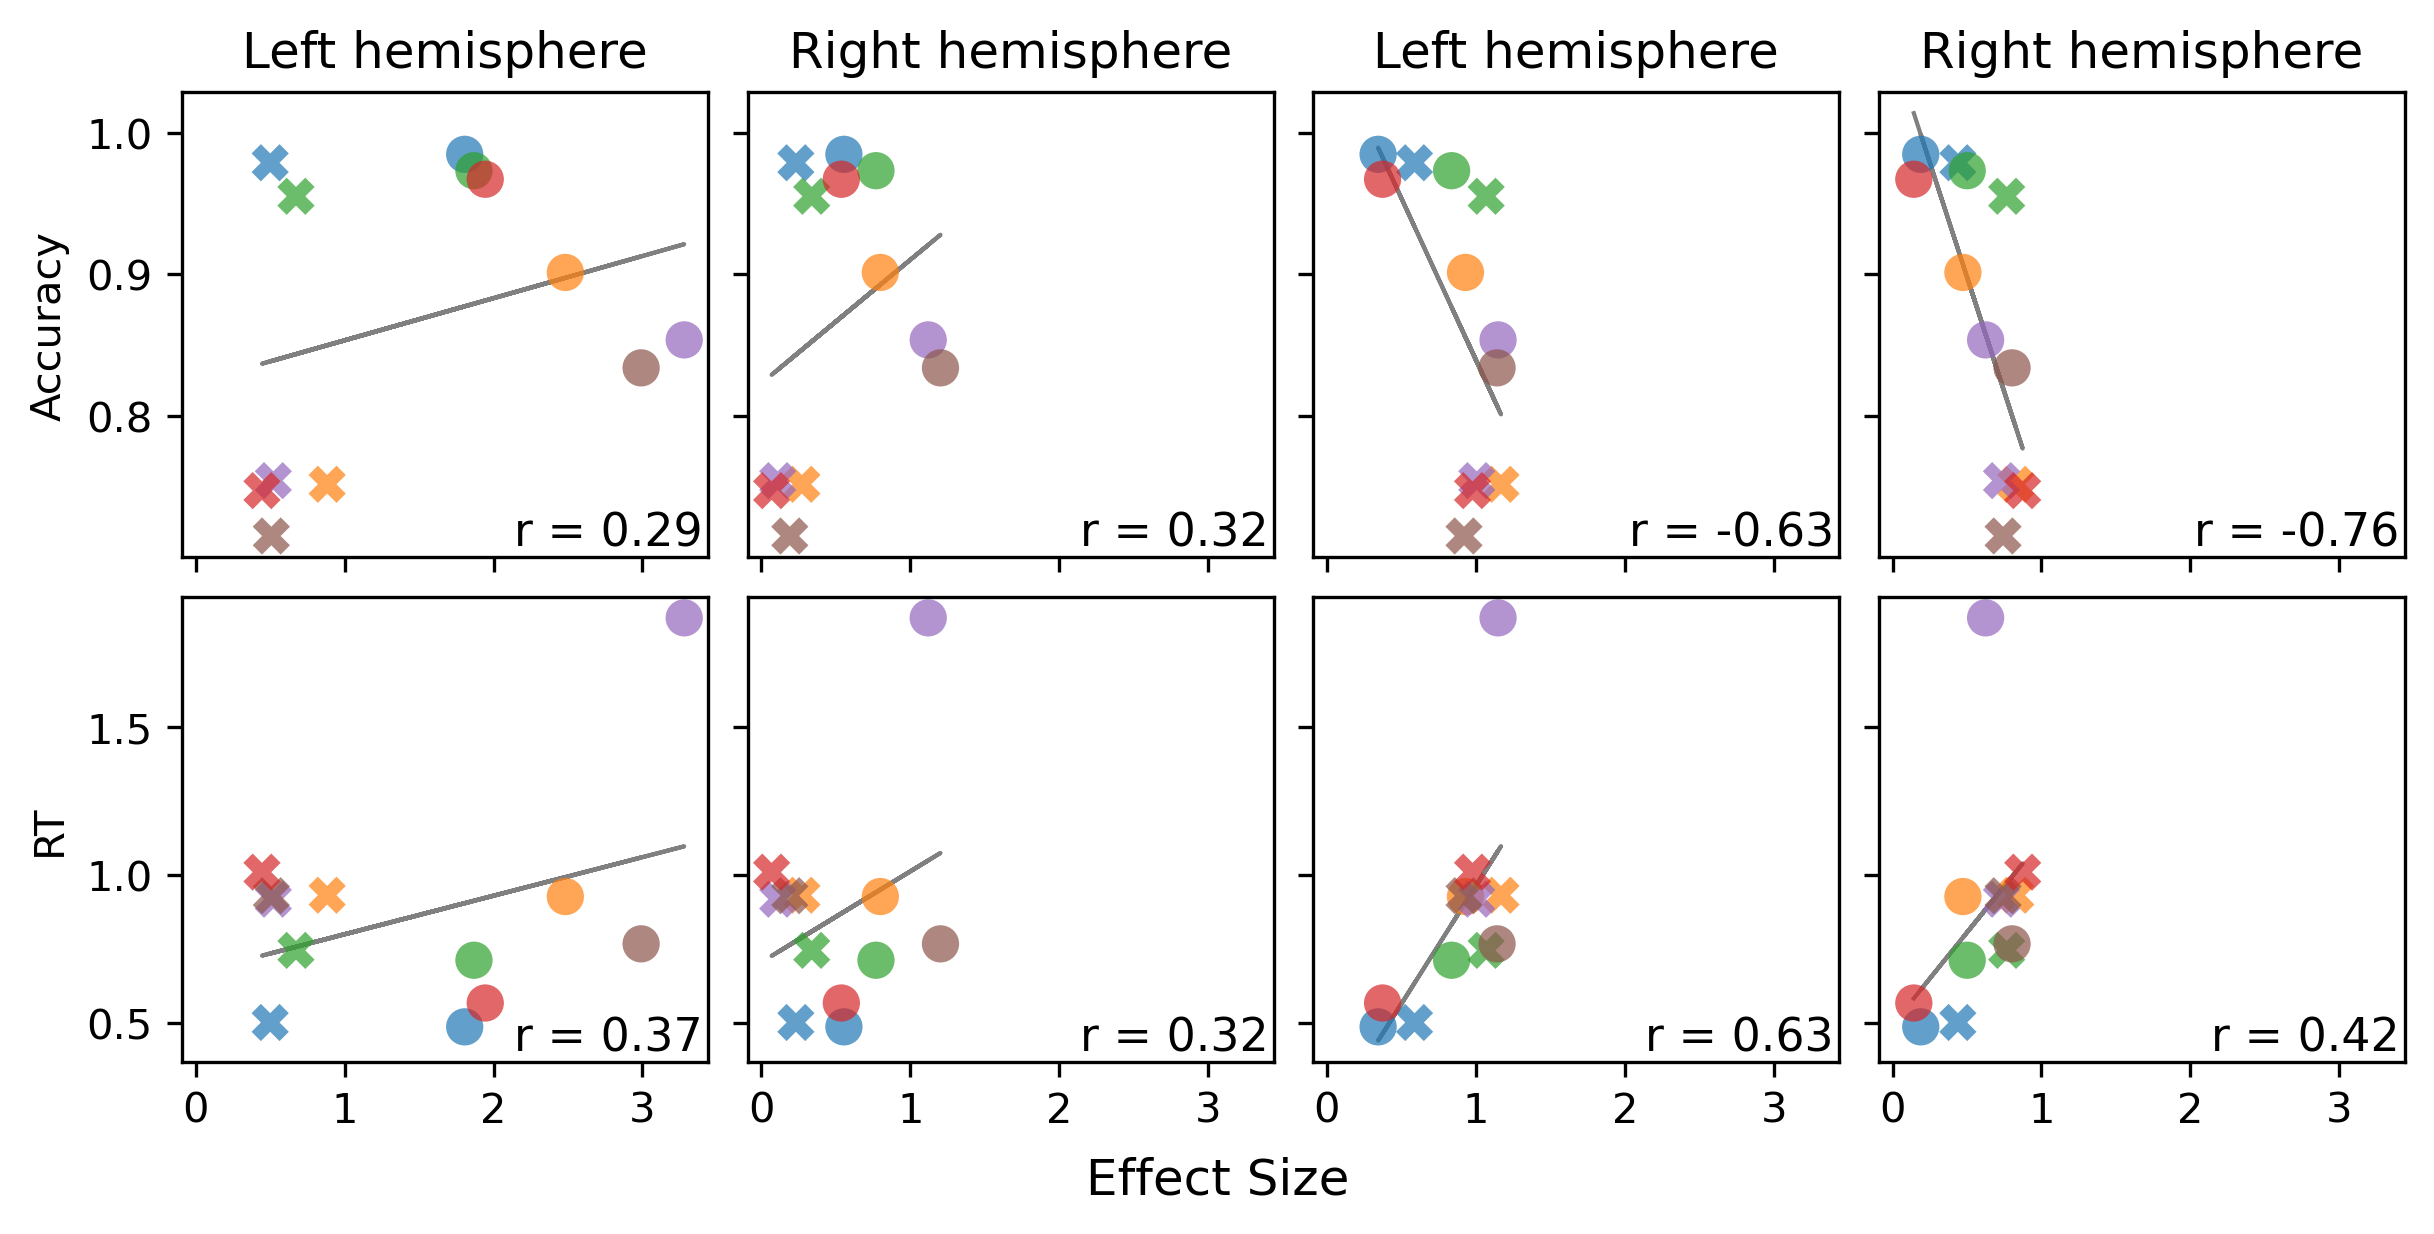

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

s = 80
r_fontsize = 11

# Data configs for plotting: each tuple is (title, data, col_index)
plot_configs = [
    ('Left hemisphere', data_language_lh),
    ('Right hemisphere', data_language_rh),
    ('Left hemisphere', data_md_lh),
    ('Right hemisphere', data_md_rh),
]

# Initialize one figure: 2 rows (accuracy, RT), 4 columns (LH/RH x Lang/MD)
fig, axs = plt.subplots(2, 4, figsize=(8, 4), sharex=True, sharey='row', 
                        constrained_layout=True, dpi=300)

def plot_panel(ax, df_beh, df_task, yvar, title=None, legend=False):
    merged = pd.merge(df_beh, df_task, on=['Subject', 'Task', 'Effect'], how='left')
    merged = merged[['Task', 'Effect', 'EffectSize', yvar]].groupby(['Task', 'Effect']).mean().reset_index()    
    merged['Task'] = merged['Task'].replace({'V1': 'V1a', 'V6': 'V1b'})
    hue_order = ['V1a', 'V2', 'V3', 'V1b', 'V4', 'V5']
    sns.scatterplot(
        data=merged, x='EffectSize', y=yvar, hue='Task', style='Effect',
        style_order=['S', 'N'], s=s, linewidth=0, alpha=0.7,
        ax=ax, legend=legend, hue_order=hue_order
    )
    
    x = merged['EffectSize'].to_numpy().astype(float)
    y = merged[yvar].to_numpy().astype(float)
    valid = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, *_ = linregress(x[valid], y[valid])
    
    ax.plot(merged['EffectSize'], slope * merged['EffectSize'] + intercept,
            color='gray', linestyle='-', linewidth=1, zorder=0)
    ax.text(0.99, 0.1, f'r = {r_value:.2f}', transform=ax.transAxes,
            fontsize=r_fontsize, va='top', ha='right')

    # print pearson correlation and p-value
    pearson_corr = np.corrcoef(x[valid], y[valid])[0, 1]
    p_value = linregress(x[valid], y[valid]).pvalue
    print(f'Pearson correlation: {pearson_corr:.2f}, p-value: {p_value:.4f}')

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')

# First row: Accuracy plots
for col, (title, df_task) in enumerate(plot_configs):
    ax = axs[0, col]
    plot_panel(ax, df_beh, df_task, yvar='Accuracy', title=title, legend=False)

# Second row: RT plots
for col, (_, df_task) in enumerate(plot_configs):
    ax = axs[1, col]
    plot_panel(ax, df_beh, df_task, yvar='RT', title='', legend=False)

# Axis labels
fig.supxlabel('Effect Size')
axs[0, 0].set_ylabel('Accuracy')
axs[1, 0].set_ylabel('RT')
plt.savefig(cwd / 'Figures' / 'effect_vs_bh.png', dpi=300, bbox_inches='tight',
            transparent=True)


/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_26249/3775029461.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


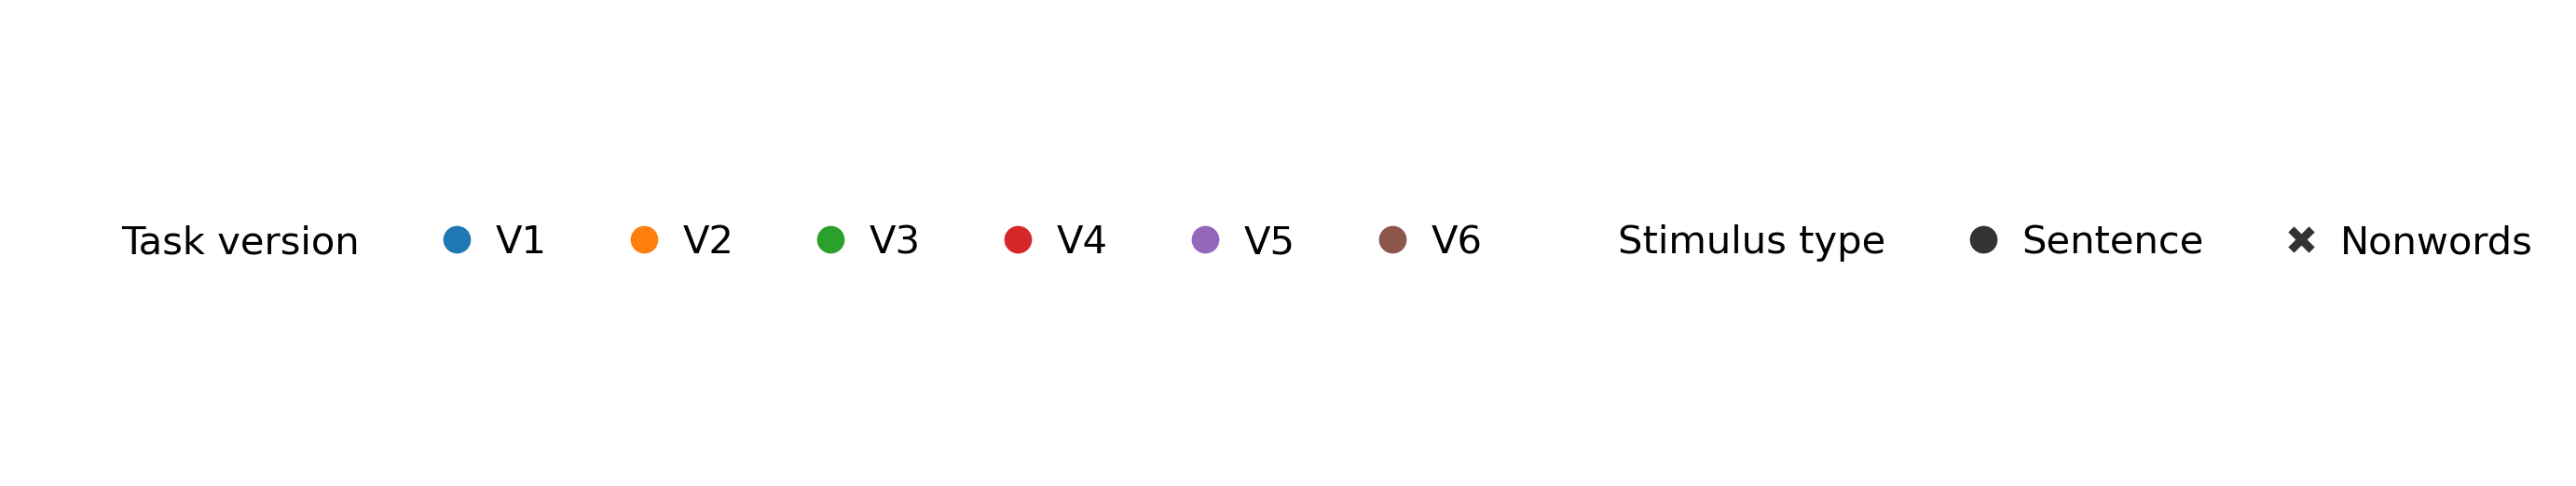

In [6]:
# Color legend
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

hue_order = [
    'V1',
    'V2', 
    'V3', 
    'V4', 
    'V5', 
    'V6']
style_order = [
    'Sentence', 
    'Nonwords'
]
palette = sns.color_palette(n_colors=len(hue_order))

dummy_data = pd.DataFrame({
    'Task version': sum([[t]*2 for t in hue_order], []),
    'Stimulus type': style_order * len(hue_order),
    'EffectSize': [0]*len(hue_order)*2,
    'Accuracy': [0]*len(hue_order)*2,
})
fig_dummy, ax_dummy = plt.subplots()
sns.scatterplot(
    data=dummy_data,
    x='EffectSize', y='Accuracy',
    hue='Task version', style='Stimulus type',
    palette=palette,
    hue_order=hue_order,
    style_order=style_order,
    s=60,
    ax=ax_dummy
)
handles, labels = ax_dummy.get_legend_handles_labels()
plt.close(fig_dummy)

fig, ax = plt.subplots(figsize=(5, 2), dpi=300)
ax.axis('off')
legend = ax.legend(
    handles=handles,
    labels=labels,
    loc='center',
    frameon=False,
    ncol=10,
    handletextpad=0,
    columnspacing=1.5
)

plt.tight_layout()
plt.savefig(cwd / 'Figures' / 'effect_vs_bh_legend.png', bbox_inches='tight', 
            dpi=300, transparent=True)
